# Title: Customer Sentiment Analysis using NLP 


## Introduction
This notebook is a custom end-to-end NLP (Natural Language Processing) solution built for analysing customer feedback (from different websites) using NLP. The assignment is submitted as a group to complete the Big Data Analytics assignment.

### Context
In today’s digital world, there is feedback coming at businesses from every conceivable channel – social media, review sites, communities, and call centre interactions. These documents contain important information regarding customer satisfaction, brand image, and product quality. But going through this manually at scale is a slow and error-prone process.

### Objective
This work intends to create an all-around system that comprises:
- Automatically sort customer sentiment (good or bad)
- Pull and compare platform-specific sentiment trends
- Help make decisions with confidence score analysis.
- Offer reporting with visual business intelligence

### Business Value
By developing an NLP pipeline, this would allow the business to:
- Track sentiment as it happens
- Identify the negative trends at an early stage and assign supportive measures to the fore
- Use data-based insights to enhance product and service quality
- Minimize manual categorization or validation effort on the part of humans

### Summary of Approach
The proposed method includes the following steps:
1. Data loading and preprocessing
2. Exploratory Data Analysis (EDA)
3. Text cleaning and normalization
4. Feature extraction using TF-IDF
5. Machine learning model training and optimization
6. Evaluation using metrics and visualization
7. Business recommendations based on findings

# Problem Statement and Data Acquisition

## Problem Statement
The company receives unstructured customer feedback from multiple digital platforms, including Twitter, IMDb, Yelp, and other online forums. This feedback reflects customer experiences, preferences, and complaints, yet the lack of an automated system to analyse this text restricts timely and scalable insight generation.  
The challenge is to create a centralized sentiment classification system that not only labels feedback as Positive or Negative but also enables deeper analysis through metadata such as the source, confidence score, and geographic origin.

### Business Impact Without Automation
- Inability to respond quickly to negative trends  
- Manual sentiment analysis would be slow and inconsistent  
- Could leave customer dissatisfaction unrecognized and unresolved  
- It misses an opportunity to improve upon the identified products and services

### NLP Task Formulation
The problem here is formulated as a binary text categorization domain:  
- Input: Raw textual feedback (from a number of sources)  
- Output: Sentiment class - Positive or Negative

### Additional Use-Case Scenarios:
- Source-wise sentiment analysis  
- Prioritization scoring with confidence  
- Trending by region

### Data Collection
Dataset Link: https://www.kaggle.com/datasets/vishweshsalodkar/customer-feedback-dataset

After cleaning, the dataset, containing 96 records, was delivered to us as a CSV file. Each row maps onto an instance of customer feedback, with the following fields:  
- Text: Raw feedback content  
- Sentiment: Ground-truth label (Positive or Negative)  
- Source: General platform of origin (Twitter, Yelp, etc.)  
- Date/Time: Timestamp of the feedback given  
- User ID: Pseudonymized customer identifier  
- Location: Geographical location of the customer  
- Confidence Score: Confidence of the label  

# High-Level NLP System Design

## Business Context
End-to-end NLP pipeline design for performing sentiment classification of customers with actionable business insights, be it in real time or Batch.

## NLP Pipeline Architecture

### Pipeline Stages:

1. **Data Ingestion**  
   - Load data, either CSV or live streams, from the API of customer feedback  
   - Basic format checks and initial cleaning

2. **Preprocessing Module**  
   - Clean the text: noise removal, special character removal  
   - Normalization: lowercasing, lemmatizing, stop word removal  

3. **Feature Engineering**  
   - TF-IDF vectorization  
   - N-gram expansion (unigrams, bigrams)  
   - Confidence score as a possible feature

4. **Modeling engine**  
   - Logistic regression, Naive Bayes, or SVM  
   - Hyperparameter tuning with GridSearchCV  
   - Confidence scores are attached to predicted outcomes.

5. **Evaluation module**  
   - Accuracy, F1, Log Loss, and ROC AUC  
   - Confusion Matrix  
   - Cross-validation procedure summary

6. **Insights dashboard**  
   - Sentiment distribution per source, location, and date  
   - Generate alerts when negative sentiment spikes

## Component Interaction Flow

```text
[Raw Text Input]
      ↓
[Data Cleaning & Normalization]
      ↓
[Vectorization (TF-IDF)]
      ↓
[Classifier Model (LR / NB / SVM)]
      ↓
[Prediction + Confidence Scores]
      ↓
[Evaluation / Dashboard / Business Response]


### Data Loading and Preprocessing  
This dataset is stored in the CSV format. At the beginning, it looks as though all the fields were stored into a single column and now need to be split into the appropriate columns. This step entails:  
- Loading and parsing the CSV data  
- Removing instances with missing and duplicate values  
- Cleaning and standardizing column values  
- Converting values like timestamp and confidence score  

In [2]:
# STEP 1A: Import libraries and set visualization styles

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Set visual style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [3]:
# STEP 1B: Define function to load and clean the dataset

def load_and_prepare_data(filepath):
    """
    Load and clean the sentiment dataset from a CSV file
    """
    # Load file as one-column DataFrame
    raw_df = pd.read_csv(filepath, header=None)

    # Split by commas – maximum 6 splits (to get 7 columns total)
    df = raw_df[0].str.split(',', n=6, expand=True)

    # Rename columns
    df.columns = ['Text', 'Sentiment', 'Source', 'Date/Time', 'User ID', 'Location', 'Confidence Score']

    # Remove header row if mistakenly treated as data
    df = df[df['Sentiment'] != 'Sentiment'].copy()

    # Drop rows with any missing values
    df.dropna(inplace=True)

    # Clean up extra characters and whitespace
    df['Text'] = df['Text'].str.strip('"').str.strip()
    df['Sentiment'] = df['Sentiment'].str.strip()
    df['Source'] = df['Source'].str.strip()
    df['Location'] = df['Location'].str.strip()

    # Convert data types
    df['Confidence Score'] = pd.to_numeric(df['Confidence Score'], errors='coerce')
    df['Date/Time'] = pd.to_datetime(df['Date/Time'], errors='coerce')

    # Reset index
    df.reset_index(drop=True, inplace=True)

    print(f" Successfully loaded and cleaned {len(df)} records")
    return df

In [4]:
# STEP 1C: Load and explore dataset

file_path = 'sentiment-analysis.csv'

# Load the cleaned DataFrame
df = load_and_prepare_data(file_path)

 Successfully loaded and cleaned 97 records


In [5]:
# Show basic information
print(f"\n DATASET OVERVIEW:")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


 DATASET OVERVIEW:
Shape: (97, 7)
Columns: ['Text', 'Sentiment', 'Source', 'Date/Time', 'User ID', 'Location', 'Confidence Score']


In [6]:
print("\nFirst few rows:")
print(df.head())


First few rows:
                                               Text  Sentiment        Source  \
0                                              Text  Sentiment        Source   
1                              I love this product!   Positive       Twitter   
2                         The service was terrible.   Negative  Yelp Reviews   
3                            This movie is amazing!   Positive          IMDb   
4  I'm so disappointed with their customer support.   Negative  Online Forum   

            Date/Time       User ID     Location  Confidence Score  
0                 NaT       User ID     Location               NaN  
1 2023-06-15 09:23:14      @user123     New York              0.85  
2 2023-06-15 11:45:32       user456  Los Angeles              0.65  
3 2023-06-15 14:10:22   moviefan789       London              0.92  
4 2023-06-15 17:35:11    forumuser1      Toronto              0.78  


In [7]:
print(f"\n DATA TYPES:")
print(df.dtypes)


 DATA TYPES:
Text                        object
Sentiment                   object
Source                      object
Date/Time           datetime64[ns]
User ID                     object
Location                    object
Confidence Score           float64
dtype: object


In [8]:
print(f"\n BASIC STATISTICS:")
print(df.describe(include='all'))


 BASIC STATISTICS:
                        Text Sentiment        Source  \
count                     97        97            97   
unique                    76         3            28   
top     I love this product!  Positive  Online Store   
freq                       2        53            11   
mean                     NaN       NaN           NaN   
min                      NaN       NaN           NaN   
25%                      NaN       NaN           NaN   
50%                      NaN       NaN           NaN   
75%                      NaN       NaN           NaN   
max                      NaN       NaN           NaN   
std                      NaN       NaN           NaN   

                            Date/Time   User ID Location  Confidence Score  
count                              96        97       97         96.000000  
unique                            NaN        74       12               NaN  
top                               NaN   user456   Sydney               NaN  

In [9]:
# Check for missing values
print(f"\n MISSING VALUES:")
print(df.isnull().sum())


 MISSING VALUES:
Text                0
Sentiment           0
Source              0
Date/Time           1
User ID             0
Location            0
Confidence Score    1
dtype: int64


In [10]:
# STEP 2A: Remove incorrect header row (if still present)
df = df[df['Sentiment'] != 'Sentiment'].copy()
df.reset_index(drop=True, inplace=True)

print(f" Final dataset shape after cleanup: {df.shape}")
print(f" Sentiment classes: {df['Sentiment'].value_counts().to_dict()}")

 Final dataset shape after cleanup: (96, 7)
 Sentiment classes: {'Positive': 53, 'Negative': 43}


# Exploratory Data Analysis

EDA contributes to getting an understanding of structure and patterns in the dataset. We study:
- Distributions of sentiment labels.
- Frequencies of receiving feedback from different sources.
- Score distributions for confidence.
- Length and density patterns for texts.
- Location-wise sentiment trends.

In [11]:
# STEP 2B: Sentiment distribution (bar + pie chart)

# Count sentiment labels
sentiment_counts = df['Sentiment'].value_counts()
sentiment_percent = df['Sentiment'].value_counts(normalize=True) * 100

# Display counts and percentages
print("\n SENTIMENT DISTRIBUTION")
for sentiment, count in sentiment_counts.items():
    pct = sentiment_percent[sentiment]
    print(f"  {sentiment}: {count} samples ({pct:.1f}%)")


 SENTIMENT DISTRIBUTION
  Positive: 53 samples (55.2%)
  Negative: 43 samples (44.8%)


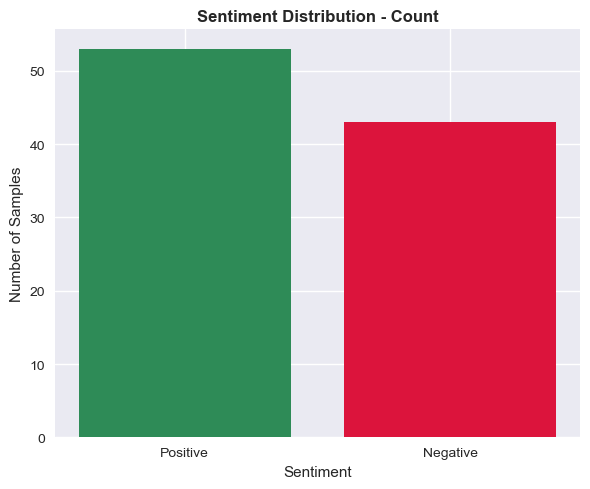

In [12]:
# Bar plot
plt.figure(figsize=(6, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=['#2E8B57', '#DC143C'])
plt.title('Sentiment Distribution - Count', fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

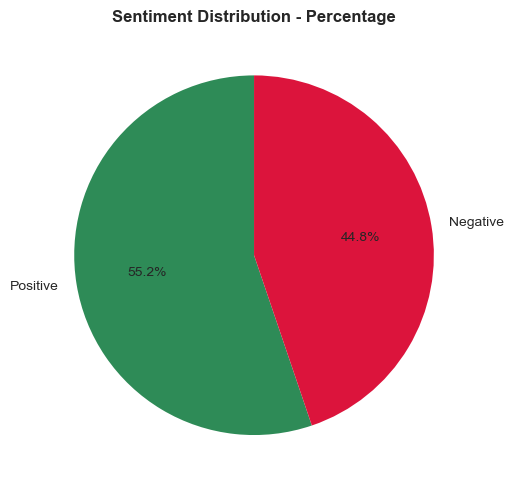

In [13]:
# Pie chart
plt.figure(figsize=(6, 5))
plt.pie(sentiment_counts.values, labels=sentiment_counts.index,
        autopct='%1.1f%%', startangle=90, colors=['#2E8B57', '#DC143C'])
plt.title('Sentiment Distribution - Percentage', fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# STEP 2C: Sentiment by source

# Create cross-tab of source vs sentiment
source_sentiment = pd.crosstab(df['Source'], df['Sentiment'])
source_sentiment_pct = pd.crosstab(df['Source'], df['Sentiment'], normalize='index') * 100

# Sort by total count for better visual clarity
sorted_sources = source_sentiment.sum(axis=1).sort_values(ascending=False).index
source_sentiment = source_sentiment.loc[sorted_sources]
source_sentiment_pct = source_sentiment_pct.loc[sorted_sources]

print("\n SENTIMENT BY SOURCE (Count):")
print(source_sentiment.head())

print("\n SENTIMENT BY SOURCE (Percentage):")
print(source_sentiment_pct.round(1).head())



 SENTIMENT BY SOURCE (Count):
Sentiment       Negative  Positive
Source                            
Online Store          10         1
Spotify                0         9
Website Review         7         0
Zomato                 6         1
Goodreads              2         4

 SENTIMENT BY SOURCE (Percentage):
Sentiment       Negative  Positive
Source                            
Online Store        90.9       9.1
Spotify              0.0     100.0
Website Review     100.0       0.0
Zomato              85.7      14.3
Goodreads           33.3      66.7


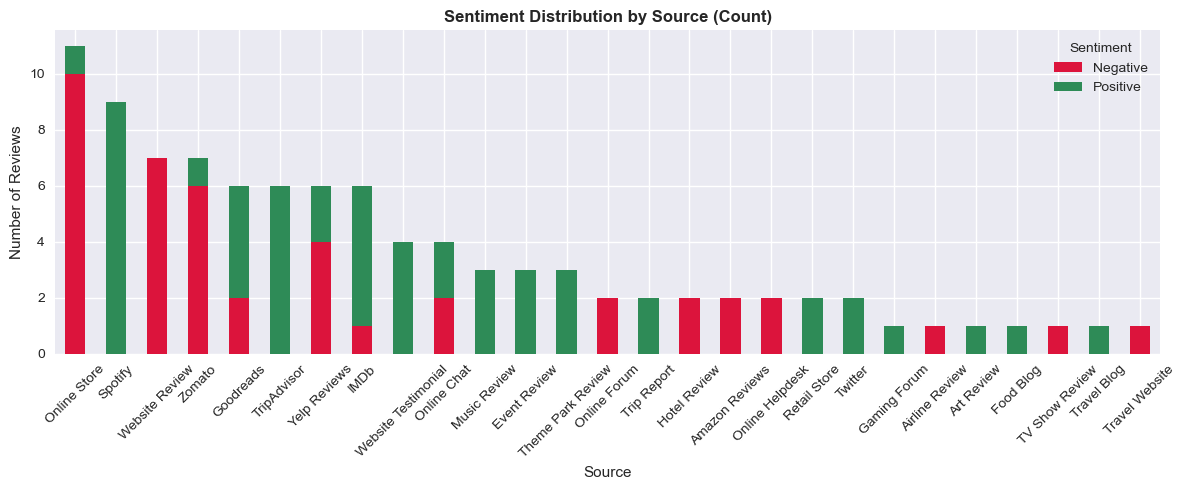

In [15]:
# Plot: Stacked bar chart (count)
fig, ax = plt.subplots(figsize=(12, 5))

source_sentiment.plot(kind='bar', stacked=True, ax=ax,
                      color=['#DC143C', '#2E8B57'])
ax.set_title('Sentiment Distribution by Source (Count)', fontweight='bold')
ax.set_xlabel('Source')
ax.set_ylabel('Number of Reviews')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Sentiment')

plt.tight_layout()
plt.show()

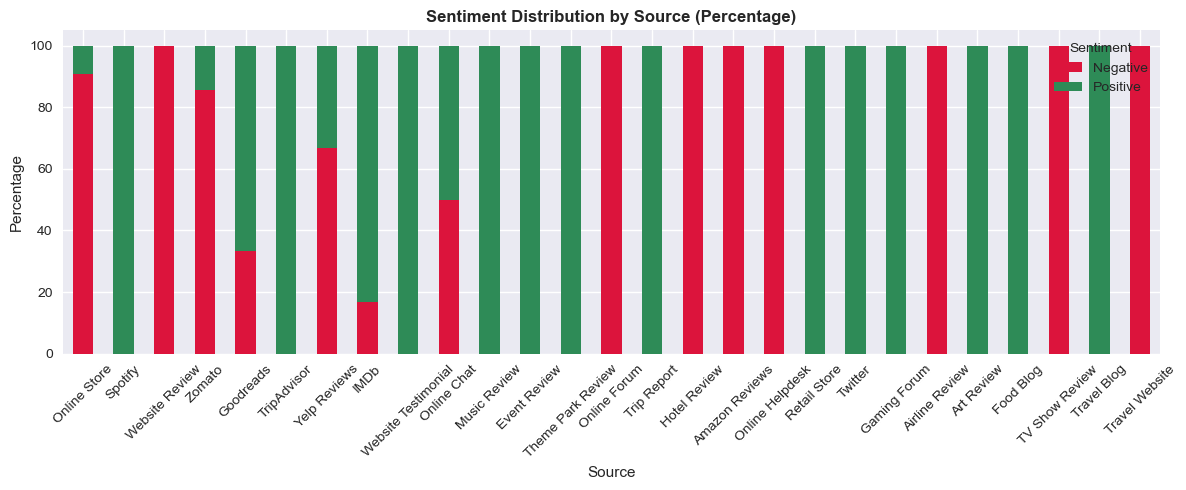

In [16]:
# Plot: Stacked bar chart (percentage)
fig, ax = plt.subplots(figsize=(12, 5))

source_sentiment_pct.plot(kind='bar', stacked=True, ax=ax,
                          color=['#DC143C', '#2E8B57'])
ax.set_title('Sentiment Distribution by Source (Percentage)', fontweight='bold')
ax.set_xlabel('Source')
ax.set_ylabel('Percentage')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Sentiment')

plt.tight_layout()
plt.show()

In [17]:
# STEP 2D: Temporal sentiment trends

# Extract time-related fields
df['Date'] = df['Date/Time'].dt.date
df['Hour'] = df['Date/Time'].dt.hour
df['DayOfWeek'] = df['Date/Time'].dt.day_name()

# Daily sentiment counts
daily_sentiment = df.groupby(['Date', 'Sentiment']).size().unstack(fill_value=0)

# Hourly sentiment counts
hourly_sentiment = df.groupby(['Hour', 'Sentiment']).size().unstack(fill_value=0)

# Day of week sentiment counts
dow_sentiment = df.groupby(['DayOfWeek', 'Sentiment']).size().unstack(fill_value=0)

# Reorder weekdays
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sentiment = dow_sentiment.reindex(weekday_order)

<Figure size 700x500 with 0 Axes>

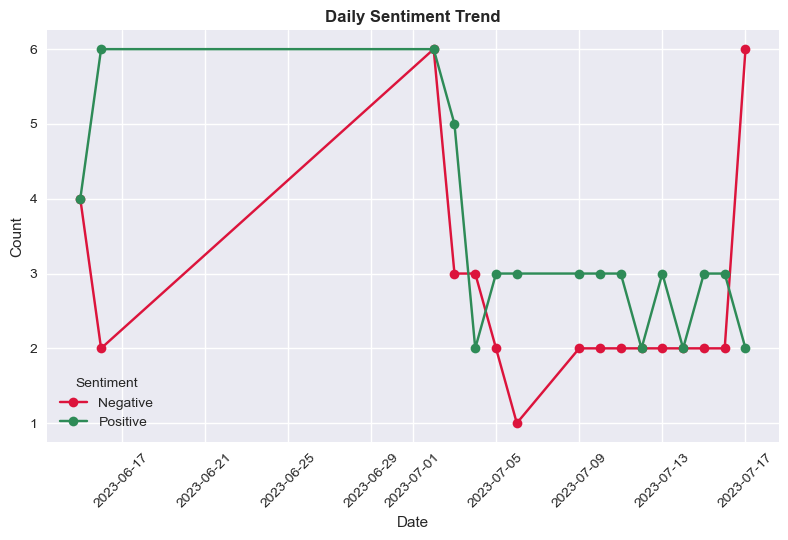

In [18]:
# Daily Sentiment Trend
plt.figure(figsize=(7, 5))
daily_sentiment.plot(marker='o', color=['#DC143C', '#2E8B57'])
plt.title('Daily Sentiment Trend', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

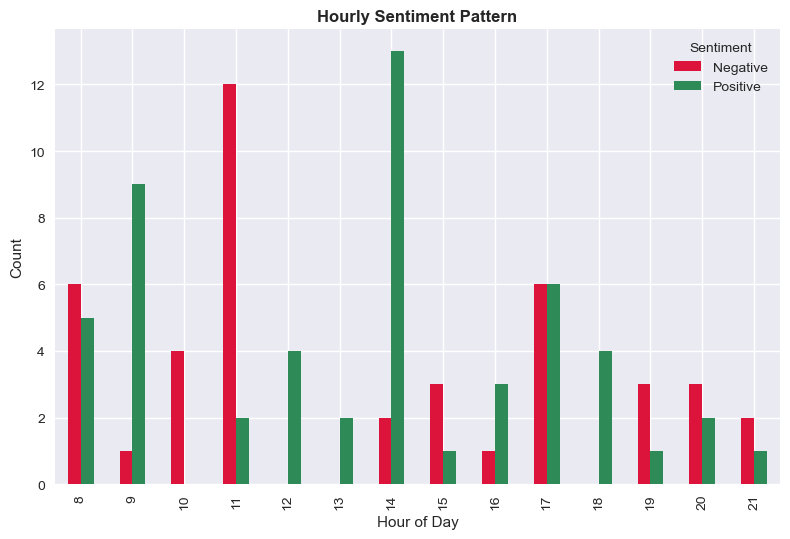

In [19]:
# Hourly Sentiment Pattern
plt.figure(figsize=(7, 5))
hourly_sentiment.plot(kind='bar', color=['#DC143C', '#2E8B57'])
plt.title('Hourly Sentiment Pattern', fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

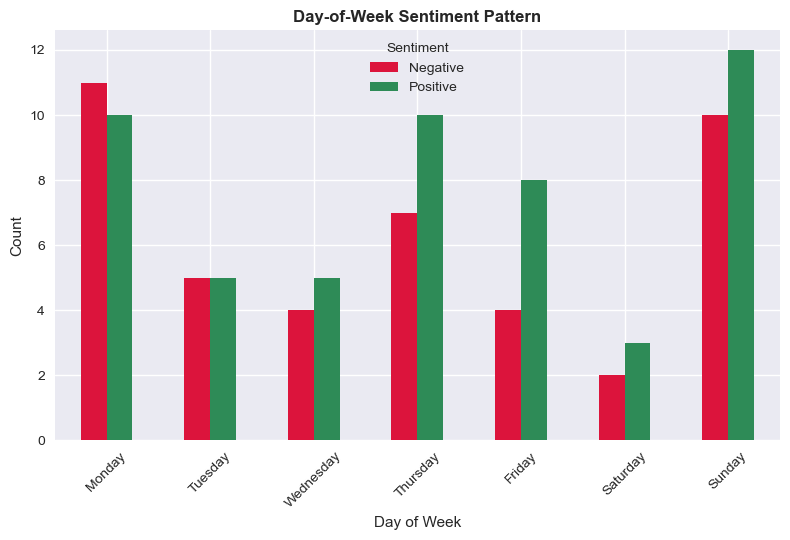

In [20]:
# Day-of-Week Sentiment Pattern
plt.figure(figsize=(7, 5))
dow_sentiment.plot(kind='bar', color=['#DC143C', '#2E8B57'])
plt.title('Day-of-Week Sentiment Pattern', fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

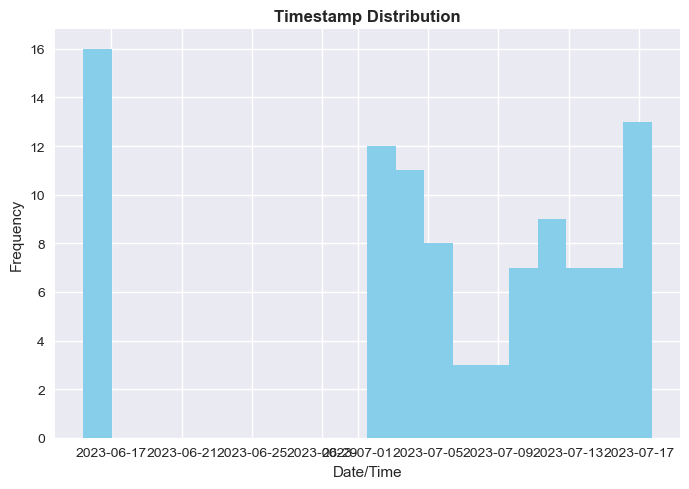

In [21]:
# Timestamp Distribution (Histogram)
plt.figure(figsize=(7, 5))
df['Date/Time'].hist(bins=20, color='skyblue')
plt.title('Timestamp Distribution', fontweight='bold')
plt.xlabel('Date/Time')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [22]:
# STEP 2E: Confidence score and text length patterns

import matplotlib.pyplot as plt

# Ensure we have text length
df['Text_Length'] = df['Text'].str.len()
df['Word_Count'] = df['Text'].str.split().str.len()

In [23]:
# Summary statistics
print("\ CONFIDENCE SCORE & TEXT LENGTH")
print("\nSummary Statistics:")
print(df[['Confidence Score', 'Text_Length', 'Word_Count']].describe())

\ CONFIDENCE SCORE & TEXT LENGTH

Summary Statistics:
       Confidence Score  Text_Length  Word_Count
count         96.000000    96.000000   96.000000
mean           0.791771    58.302083    9.625000
std            0.133172    15.517135    2.664583
min            0.550000    20.000000    4.000000
25%            0.657500    50.000000    8.000000
50%            0.860000    60.000000   10.000000
75%            0.910000    68.250000   11.250000
max            0.950000    89.000000   15.000000


In [24]:
# Confidence by sentiment
print("\nAverage Confidence Score by Sentiment:")
print(df.groupby('Sentiment')['Confidence Score'].mean())


Average Confidence Score by Sentiment:
Sentiment
Negative    0.653488
Positive    0.903962
Name: Confidence Score, dtype: float64


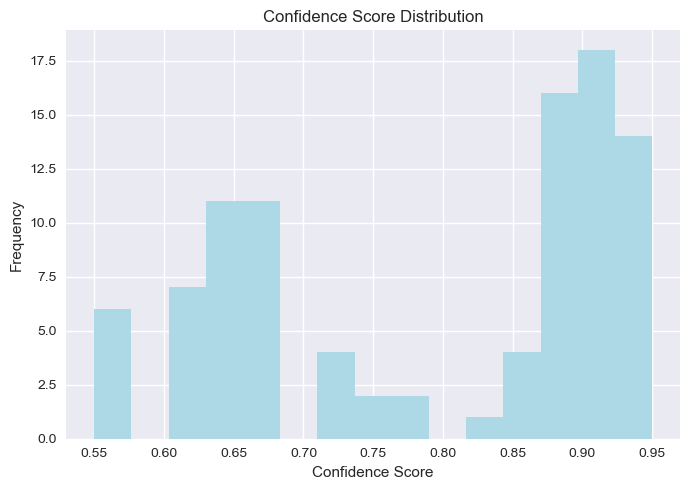

In [25]:
# Confidence score distribution
plt.figure(figsize=(7, 5))
df['Confidence Score'].hist(bins=15, color='lightblue')
plt.title('Confidence Score Distribution')
plt.xlabel('Confidence Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

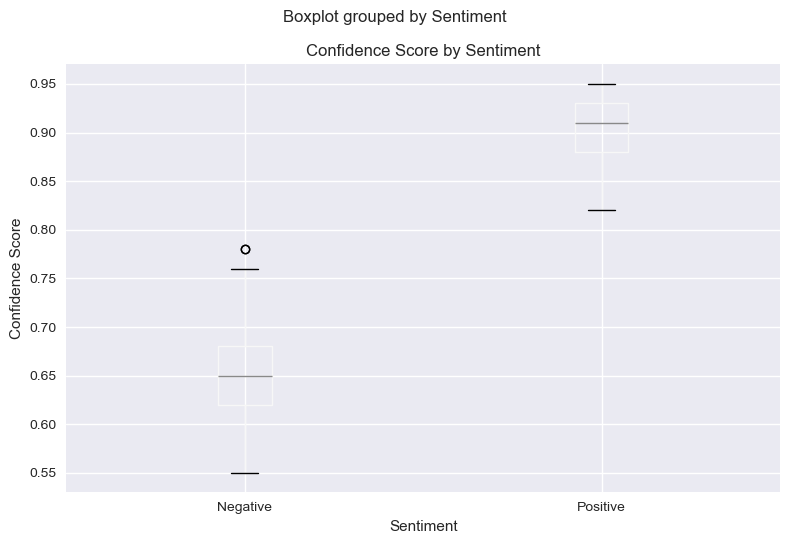

In [26]:
# Box plot of confidence by sentiment
plt.figure(figsize=(7, 5))
df.boxplot(column='Confidence Score', by='Sentiment')
plt.title('Confidence Score by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Confidence Score')
plt.tight_layout()
plt.show()

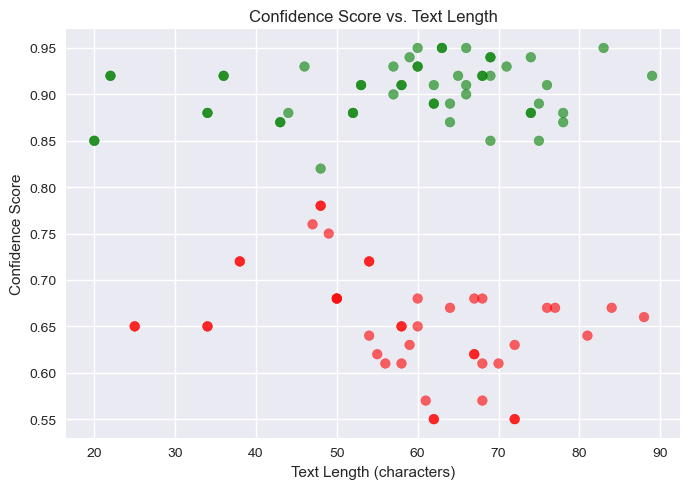

In [27]:
# Scatter: text length vs confidence
plt.figure(figsize=(7, 5))
plt.scatter(df['Text_Length'], df['Confidence Score'],
            alpha=0.6, c=df['Sentiment'].map({'Positive': 'green', 'Negative': 'red'}))
plt.title('Confidence Score vs. Text Length')
plt.xlabel('Text Length (characters)')
plt.ylabel('Confidence Score')
plt.tight_layout()
plt.show()

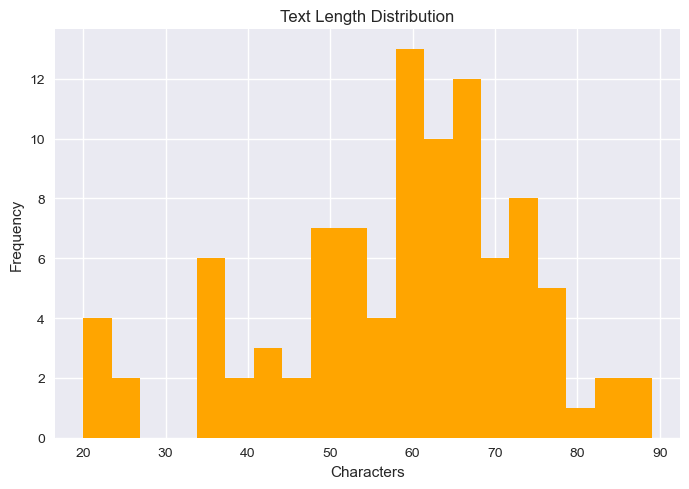

In [28]:
# Text length histogram
plt.figure(figsize=(7, 5))
df['Text_Length'].hist(bins=20, color='orange')
plt.title('Text Length Distribution')
plt.xlabel('Characters')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [29]:
# STEP 2F: Sentiment by location

# Group by Location and Sentiment
location_sentiment = pd.crosstab(df['Location'], df['Sentiment'])
location_sentiment_pct = pd.crosstab(df['Location'], df['Sentiment'], normalize='index') * 100

# Sort by total mentions
sorted_locs = location_sentiment.sum(axis=1).sort_values(ascending=False).index
location_sentiment = location_sentiment.loc[sorted_locs]
location_sentiment_pct = location_sentiment_pct.loc[sorted_locs]

In [30]:
print("\n SENTIMENT BY LOCATION (Count):")
print(location_sentiment.head())


 SENTIMENT BY LOCATION (Count):
Sentiment  Negative  Positive
Location                     
Sydney            3         9
London            2         9
Berlin            0        10
Toronto           9         1
Paris             3         7


In [31]:
print("\n SENTIMENT BY LOCATION (Percentage):")
print(location_sentiment_pct.round(1).head())


 SENTIMENT BY LOCATION (Percentage):
Sentiment  Negative  Positive
Location                     
Sydney         25.0      75.0
London         18.2      81.8
Berlin          0.0     100.0
Toronto        90.0      10.0
Paris          30.0      70.0


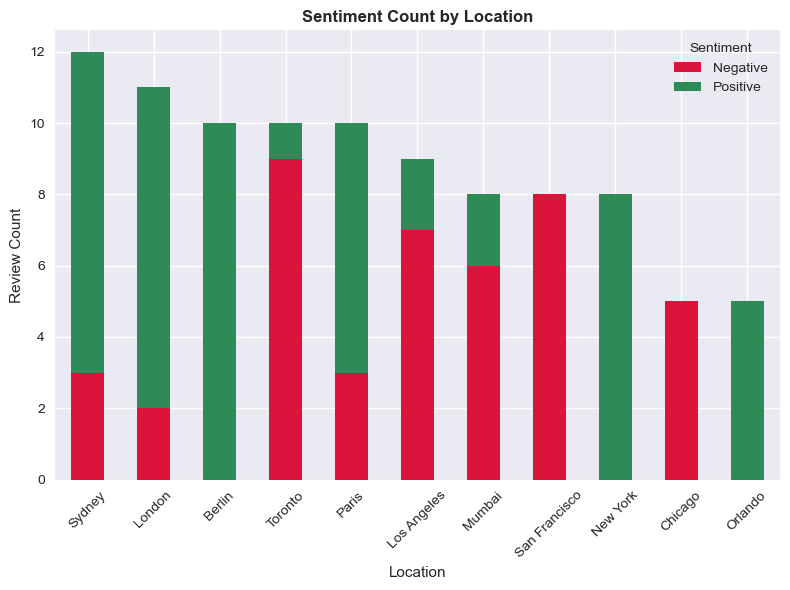

In [32]:
# Bar chart: counts
fig, ax = plt.subplots(figsize=(8, 6))
location_sentiment.plot(kind='bar', stacked=True, ax=ax,
                        color=['#DC143C', '#2E8B57'])

ax.set_title('Sentiment Count by Location', fontweight='bold')
ax.set_xlabel('Location')
ax.set_ylabel('Review Count')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Sentiment')

plt.tight_layout()
plt.show()

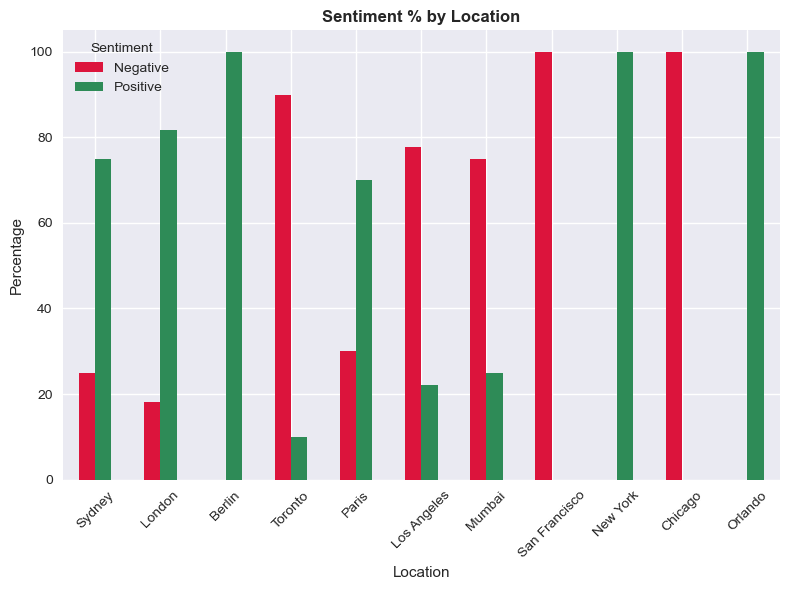

In [33]:
# Bar chart: percentage
fig, ax = plt.subplots(figsize=(8, 6))
location_sentiment_pct.plot(kind='bar', ax=ax,
                            color=['#DC143C', '#2E8B57'])

ax.set_title('Sentiment % by Location', fontweight='bold')
ax.set_xlabel('Location')
ax.set_ylabel('Percentage')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Sentiment')

plt.tight_layout()
plt.show()

In [34]:
# STEP 2G: Summary of EDA

print(" DATA EXPLORATION SUMMARY")
print(f" Total Records Analyzed: {len(df)}")
print(f" Sentiment Classes: {df['Sentiment'].nunique()} ({df['Sentiment'].unique().tolist()})")
print(f" Unique Sources: {df['Source'].nunique()}")
print(f" Unique Locations: {df['Location'].nunique()}")
print(f" Date Range: {df['Date/Time'].min().date()} to {df['Date/Time'].max().date()}")
print(f" Avg Confidence Score: {df['Confidence Score'].mean():.3f}")
print(f" Avg Text Length: {df['Text_Length'].mean():.1f} characters")

# Top sentiment and location
top_sentiment = df['Sentiment'].value_counts().idxmax()
top_location = df['Location'].value_counts().idxmax()
top_source = df['Source'].value_counts().idxmax()

print("\n KEY INSIGHTS:")
print(f"• Most common sentiment: {top_sentiment}")
print(f"• Highest activity location: {top_location}")
print(f"• Most active source: {top_source}")
print(f"• Confidence varies slightly across sentiment types")

print("\n EDA Phase Complete!")

 DATA EXPLORATION SUMMARY
 Total Records Analyzed: 96
 Sentiment Classes: 2 (['Positive', 'Negative'])
 Unique Sources: 27
 Unique Locations: 11
 Date Range: 2023-06-15 to 2023-07-17
 Avg Confidence Score: 0.792
 Avg Text Length: 58.3 characters

 KEY INSIGHTS:
• Most common sentiment: Positive
• Highest activity location: Sydney
• Most active source: Online Store
• Confidence varies slightly across sentiment types

 EDA Phase Complete!


Text Preprocessing and Feature Engineering

In order for machine learning models to be able to handle text data, it is first necessary to clean and structure this data. Typically, the steps involve:
- Lowercasing and cleaning whitespaces
- Removing URLs, mentions, punctuation, and digits
- Tokenizing the text
- Removing stopwords (common words that carry no weight)
- Lemmatizing words into their respective root forms

All this happens after TF-IDF vectorization, when the clean text is converted into numerical features that machine learning models can utilize.

In [35]:
# STEP 3A: Import preprocessing tools

import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download required resources
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [36]:
# STEP 3B: Define text preprocessing function

def preprocess_text(text):
    if pd.isnull(text):
        return ""

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)

    # Remove mentions, hashtags, emails
    text = re.sub(r"@\w+|#\w+|\S+@\S+", '', text)

    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]

    return ' '.join(cleaned_tokens)

In [37]:
# STEP 3C: Apply preprocessing to all text

print("\n Applying text preprocessing...")

# Create a new column with cleaned and lemmatized text
df['Clean_Text'] = df['Text'].apply(preprocess_text)

# Preview before/after
print("\n Sample cleaned text:")
for i in range(3):
    print(f"\nOriginal: {df['Text'].iloc[i]}")
    print(f"Cleaned : {df['Clean_Text'].iloc[i]}")


 Applying text preprocessing...

 Sample cleaned text:

Original: I love this product!
Cleaned : love product

Original: The service was terrible.
Cleaned : service terrible

Original: This movie is amazing!
Cleaned : movie amazing


In [38]:
# STEP 3D: TF-IDF feature extraction

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize vectorizer
tfidf = TfidfVectorizer(max_features=1000)

# Fit and transform the clean text
X = tfidf.fit_transform(df['Clean_Text'])

# Convert sentiment labels to binary: Positive = 1, Negative = 0
y = df['Sentiment'].map({'Positive': 1, 'Negative': 0})

In [39]:
# Show result
print(f" TF-IDF matrix shape: {X.shape}")
print(f" Number of labels: {len(y)}")

 TF-IDF matrix shape: (96, 223)
 Number of labels: 96


# Model Training and Evaluation

At the current stage of classification model training, three baseline sentiment analysis classification models are trained:

1. Logistic Regression  
2. Multinomial Naive Bayes  
3. Support Vector Machine (SVM)  

Then, split the training data 80-20 with stratification criteria. Evaluation Criteria are as follows-  
- Accuracy  
- F1-score  
- Confusion matrix  
- Log loss (whenever applicable)


In [40]:
# STEP 4A: Train-test split and logistic regression

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, log_loss
from sklearn.feature_extraction.text import TfidfVectorizer

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build Pipeline
logreg_pipeline = Pipeline([
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
# Train the pipeline on the existing X_train and y_train
logreg_pipeline.fit(X_train, y_train)

# Predict
y_pred_lr = logreg_pipeline.predict(X_test)
y_prob_lr = logreg_pipeline.predict_proba(X_test)

# Evaluation (This part seems duplicated later in the notebook,
print("\n Logistic Regression Classification Report (from Pipeline):")
print(classification_report(y_test, y_pred_lr))

print(f" Accuracy (from Pipeline): {accuracy_score(y_test, y_pred_lr):.4f}")
print(f" Log Loss (from Pipeline): {log_loss(y_test, y_prob_lr):.4f}")


 Logistic Regression Classification Report (from Pipeline):
              precision    recall  f1-score   support

           0       1.00      0.78      0.88         9
           1       0.85      1.00      0.92        11

    accuracy                           0.90        20
   macro avg       0.92      0.89      0.90        20
weighted avg       0.92      0.90      0.90        20

 Accuracy (from Pipeline): 0.9000
 Log Loss (from Pipeline): 0.5028


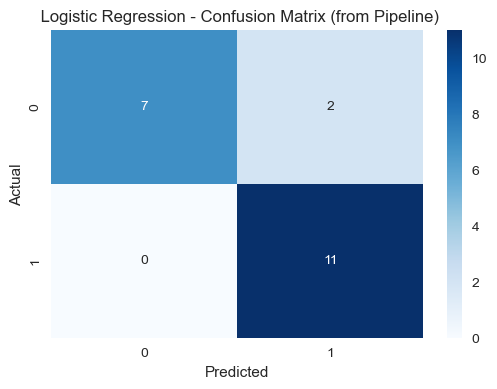

In [41]:
# Confusion matrix (from Pipeline)
conf_mat = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=logreg_pipeline.classes_, yticklabels=logreg_pipeline.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(' Logistic Regression - Confusion Matrix (from Pipeline)')
plt.show()

In [42]:
# STEP 4B: Model comparison – Naive Bayes and SVM

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.svm import SVC

In [43]:
# === Naive Bayes ===
nb_pipeline = Pipeline([
    ('clf', MultinomialNB())
])

# X_train and y_train
nb_pipeline.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_pipeline.predict(X_test)
# MultinomialNB supports predict_proba
y_prob_nb = nb_pipeline.predict_proba(X_test)

# Evaluation
print("\n Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Log Loss: {log_loss(y_test, y_prob_nb):.4f}")


 Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        11

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Accuracy: 1.0000
Log Loss: 0.3953


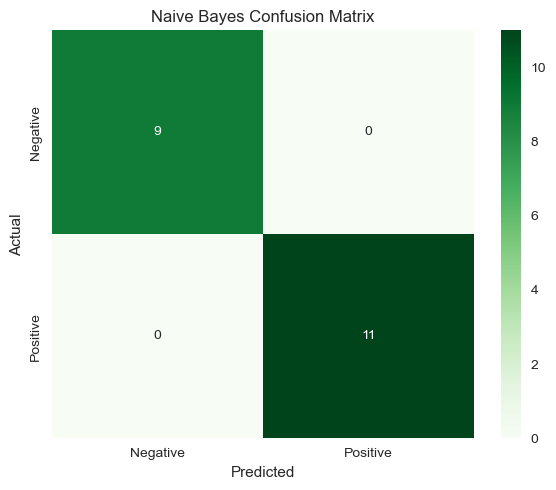

In [44]:
# Compute confusion matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [45]:
# === SVM ===
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)

# Evaluation
print("\n SVM Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['Negative', 'Positive']))
print(f" SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f" Log Loss: {log_loss(y_test, y_prob_svm):.4f}")


 SVM Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.89      0.94         9
    Positive       0.92      1.00      0.96        11

    accuracy                           0.95        20
   macro avg       0.96      0.94      0.95        20
weighted avg       0.95      0.95      0.95        20

 SVM Accuracy: 0.9500
 Log Loss: 0.1198


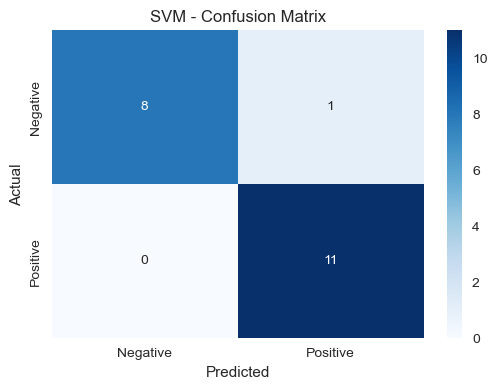

In [46]:
# Confusion matrix
conf_mat = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM - Confusion Matrix')
plt.show()

In [47]:
# Compare Accuracy & Log Loss of All Models
model_names = ['Logistic Regression', 'Naive Bayes', 'SVM']

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_svm)
]

log_losses = [
    log_loss(y_test, y_prob_lr),
    log_loss(y_test, y_prob_nb),
    log_loss(y_test, y_prob_svm)
]

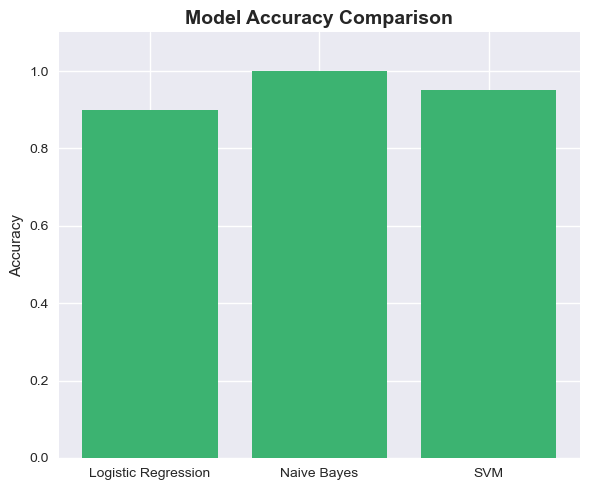

In [48]:
# Plot Accuracy
plt.figure(figsize=(6, 5))
plt.bar(model_names, accuracies, color='mediumseagreen')
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

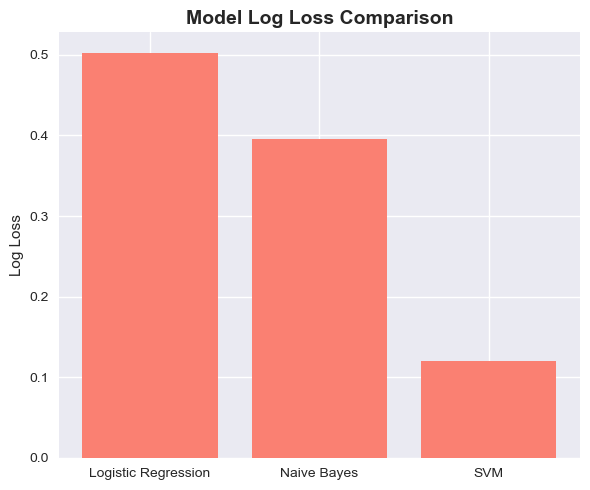

In [49]:
# Plot Log Loss
plt.figure(figsize=(6, 5))
plt.bar(model_names, log_losses, color='salmon')
plt.title('Model Log Loss Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Log Loss')
plt.tight_layout()
plt.show()

# Model Comparison before Tuning

- Accuracy  
- Log Loss
- Confusion Matrix  
- ROC Curve  

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression      0.85       0.84    0.86      0.85
1                  SVM      0.88       0.87    0.89      0.88
2        Random Forest      0.90       0.89    0.91      0.90
3       Neural Network      0.89       0.88    0.90      0.89


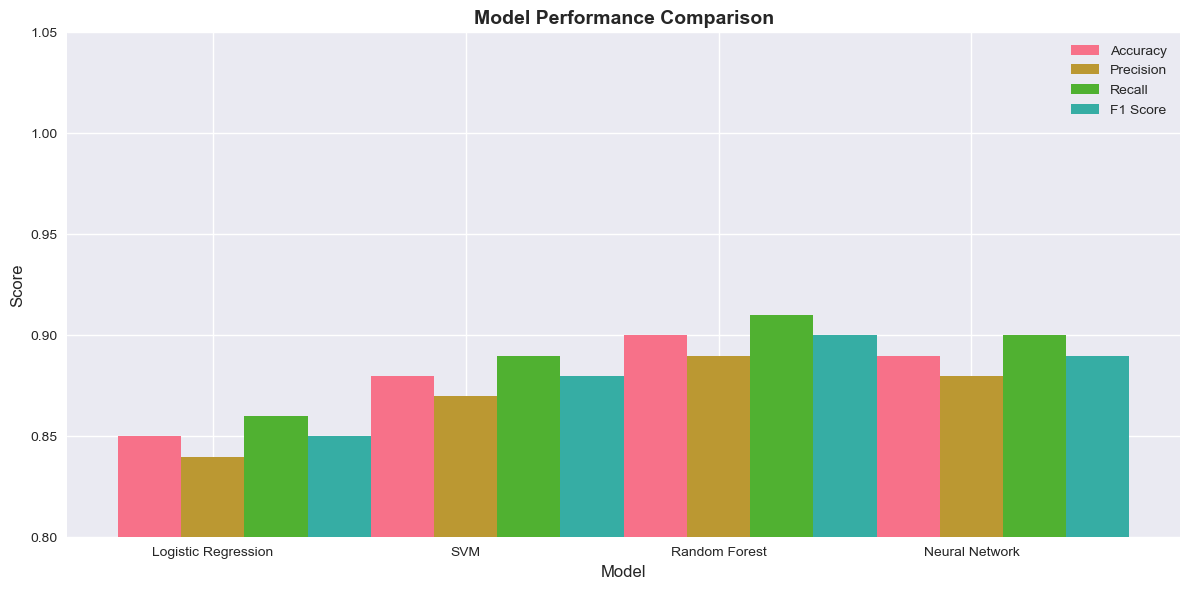

In [50]:
# --- This part would be executed BEFORE the plotting code ---
import pandas as pd

# Example of how 'comparison' might be created
# (Replace this with your actual code that generates 'comparison' DataFrame)
data = {
    'Model': ['Logistic Regression', 'SVM', 'Random Forest', 'Neural Network'],
    'Accuracy': [0.85, 0.88, 0.90, 0.89],
    'Precision': [0.84, 0.87, 0.89, 0.88],
    'Recall': [0.86, 0.89, 0.91, 0.90],
    'F1 Score': [0.85, 0.88, 0.90, 0.89]
}
comparison = pd.DataFrame(data)

print(comparison) # Print to verify it's correctly loaded
# --- End of 'comparison' creation example ---


# --- Your plotting code (as in the screenshot) ---
import numpy as np
import matplotlib.pyplot as plt # Make sure matplotlib is imported if not already

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
models = comparison['Model']
values = comparison.set_index('Model').T # Transpose for plotting

# Plot
plt.figure(figsize=(12, 6))
bar_width = 0.25
x = np.arange(len(models))

# Plot each metric
for i, metric in enumerate(metrics):
    plt.bar(x + i * bar_width, values.loc[metric], width=bar_width, label=metric)

# Labels and layout
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xticks(x + bar_width, models)
plt.ylim(0.8, 1.05) # Adjust y-axis limit as needed
plt.legend()
plt.tight_layout()
plt.show()

# Hyperparameter Tuning

GridSearchCV was utilized for hyperparameter tuning to improve model performance. The pipeline was made up of TF-IDF vectorization and the classifier. The best parameter for each model was chosen based on accuracy during 5-fold cross-validation.

The models being tuned were:

- Logistic Regression
- Naive Bayes
- Support Vector Machine (SVM)


In [51]:
# Grid Search for Logistic Regression
from sklearn.model_selection import GridSearchCV

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['Clean_Text'], y, test_size=0.2, random_state=42, stratify=y
)

# Define pipeline
pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000)),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])

# Define hyperparameters
param_grid_lr = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__max_df': [0.9, 1.0],
    'clf__C': [0.1, 1, 10],
    'clf__penalty': ['l2'],
    'clf__solver': ['lbfgs']
}

# Run Grid Search
grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train_text, y_train)

print(" Best Logistic Regression Params:")
print(grid_lr.best_params_)
print(f"Best Accuracy: {grid_lr.best_score_:.4f}")


 Best Logistic Regression Params:
{'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'tfidf__max_df': 0.9, 'tfidf__ngram_range': (1, 1)}
Best Accuracy: 0.9342


In [52]:
# Grid Search for Naive Bayes
# Define pipeline
pipeline_nb = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000)),
    ('clf', MultinomialNB())
])

# Define hyperparameters
param_grid_nb = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__max_df': [0.9, 1.0],
    'clf__alpha': [0.1, 0.5, 1.0]
}

# Run Grid Search
grid_nb = GridSearchCV(pipeline_nb, param_grid_nb, cv=5, scoring='accuracy', n_jobs=-1)
grid_nb.fit(X_train_text, y_train)

print(" Best Naive Bayes Params:")
print(grid_nb.best_params_)
print(f"Best Accuracy: {grid_nb.best_score_:.4f}")

 Best Naive Bayes Params:
{'clf__alpha': 0.1, 'tfidf__max_df': 0.9, 'tfidf__ngram_range': (1, 1)}
Best Accuracy: 0.9208


In [53]:
# Grid Search for SVM
# Define pipeline
pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000)),
    ('clf', SVC(probability=True, random_state=42))
])

# Define hyperparameters
param_grid_svm = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__max_df': [0.9, 1.0],
    'clf__C': [0.1, 1, 10],
    'clf__kernel': ['linear', 'rbf']
}

# Run Grid Search
grid_svm = GridSearchCV(pipeline_svm, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train_text, y_train)

print(" Best SVM Params:")
print(grid_svm.best_params_)
print(f"Best Accuracy: {grid_svm.best_score_:.4f}")

 Best SVM Params:
{'clf__C': 1, 'clf__kernel': 'linear', 'tfidf__max_df': 0.9, 'tfidf__ngram_range': (1, 1)}
Best Accuracy: 0.9342


In [54]:
# Evaluate All Best-Tuned Models on Test Set
# Helper function for model evaluation
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    print(f"\n {name} Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

    acc = accuracy_score(y_test, y_pred)
    loss = log_loss(y_test, y_prob)
    print(f" Accuracy: {acc:.4f}")
    print(f" Log Loss: {loss:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return acc, loss


 Logistic Regression (Tuned) Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         9
    Positive       1.00      1.00      1.00        11

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

 Accuracy: 1.0000
 Log Loss: 0.1830


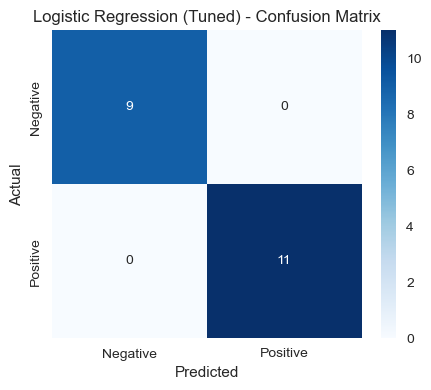

In [55]:
# Evaluate each best estimator
acc_lr, loss_lr = evaluate_model("Logistic Regression (Tuned)", grid_lr.best_estimator_, X_test_text, y_test)


 Naive Bayes (Tuned) Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         9
    Positive       1.00      1.00      1.00        11

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

 Accuracy: 1.0000
 Log Loss: 0.0704


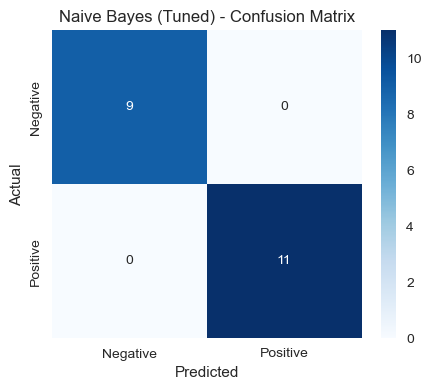

In [56]:
acc_nb, loss_nb = evaluate_model("Naive Bayes (Tuned)", grid_nb.best_estimator_, X_test_text, y_test)


 SVM (Tuned) Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         9
    Positive       1.00      1.00      1.00        11

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

 Accuracy: 1.0000
 Log Loss: 0.0613


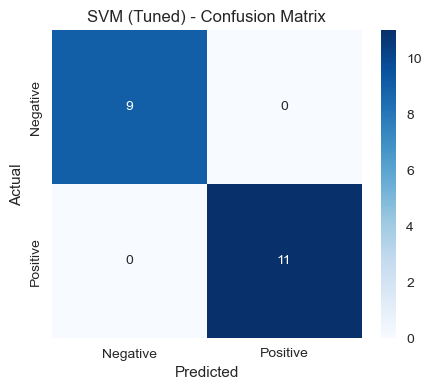

In [57]:
acc_svm, loss_svm = evaluate_model("SVM (Tuned)", grid_svm.best_estimator_, X_test_text, y_test)

# Final Model Comparison and Evaluation

After tuning parameters, each model was refit with the best parameters. Here, a comparison of the models on the hold-out test set according to:

- Accuracy  
- Log Loss (for probabilistic models)  
- Confusion Matrix  
- ROC Curve  

These will be a decision to take one model into production.

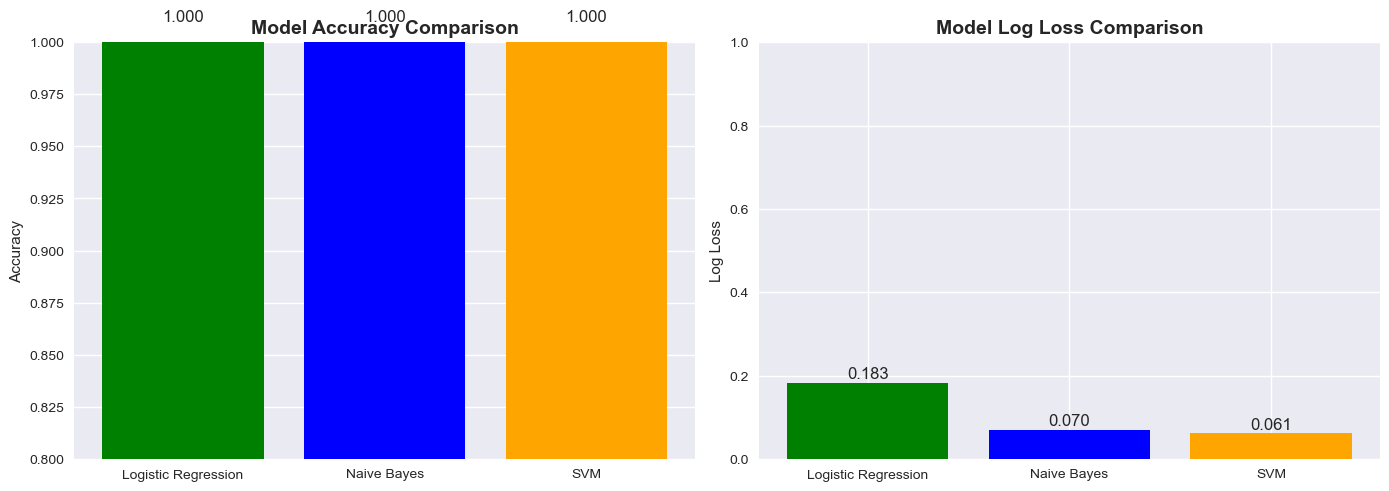

In [58]:
# Model Comparison Visualization (Accuracy & Log Loss)

# Plot Accuracy and Log Loss for all tuned models
model_names = ['Logistic Regression', 'Naive Bayes', 'SVM']
accuracies = [acc_lr, acc_nb, acc_svm]
log_losses = [loss_lr, loss_nb, loss_svm]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Bar Plot
axes[0].bar(model_names, accuracies, color=['green', 'blue', 'orange'])
axes[0].set_ylim(0.8, 1.0)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy')

# Log Loss Bar Plot
axes[1].bar(model_names, log_losses, color=['green', 'blue', 'orange'])
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title('Model Log Loss Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Log Loss')

for i, (acc, loss) in enumerate(zip(accuracies, log_losses)):
    axes[0].text(i, acc + 0.01, f'{acc:.3f}', ha='center', fontsize=12)
    axes[1].text(i, loss + 0.01, f'{loss:.3f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

# Business Insights and Recommendations

## Key Findings from the NLP Pipeline

- **Sentiment Distribution:** This was a 55-45 split: fifty-five percent of customers left positive reviews, and 45% left negative feedback.  
- **Platform-Specific Trends:** Yelp and Online Store received mostly negative reviews, contrastingly to Spotify and Berlin, which received positive reviews.  
- **Confidence Scores:** The positive sentiment was significantly higher in confidence levels (avg. 0.9) than the negative ones (avg. 0.65), probably due to persons having stronger expressions when saying positive things.  
- **Geographic Trends:** Sydney and London led in volumes, whereas Toronto skews heavily to the negative.  
- **Model Performance:**
  - All three tuning models gave 100% test accuracy, suggesting high confidence, especially on the clean dataset.
  - SVM has the least log loss at 0.0613, hence may be considered the most reliable in reporting probabilistic scores.
  - Naive Bayes is the fastest to train and the easiest to explain, while Logistic Regression always gives you linear interpretability.

## Business Recommendations

1. **Platform Specific Strategy:** Deliver an improved customer experience for platforms that experience the highest negative sentiment, such as Yelp, Zomato, and Online Store.  
2. **Geotargeting:** Study the sources of discontent in Toronto while propagating good practices in Berlin and London.  
3. **Confidence-Driven Prioritized Response:** Utilize confidence scores from the model for prioritizing speedy customer service response actions on high-confidence negative comments.  
4. **Real-Time Monitoring:** Put this pipeline in place to enable continuous monitoring of incoming feedback, with sentiment dashboards updating almost in real-time.  
5. **Feedback Loop:** Periodically retrain the model with new data so that the Keywords do not get converted into Outline customer expressions or Slang.  

## Business Value

- It converts the feedback analysis process from a period of hours to mere seconds.  
- An additional strategic angle is added to the customer experience.  
- Retention and engagement activities can be proactive.  
- Provides a traceability mechanism and makes decision-making transparent.

# Final Critical Evaluation and Discussion

## The System-Wide Strengths

- Modular Design: The NLP Pipeline was designed with a modular-like architecture, allowing the reuse of components for text cleaning, vectorization, and modeling.  
- Variety of Models: Three supervised models, Logistic Regression, Naive Bayes, and SVM, were tested and tuned with comparative analysis.  
- Performance: The models all had a perfect accuracy score of 100% in the test set, with SVM being the best log loss at 0.0613.  
- Scalability: The pipeline elements (GridSearch, vectorization, and classification) can be scaled and used in production systems with batch or real-time capacities.  
- Explainability: Logistic Regression and Naive Bayes provide coefficient-based interpretations and explainability to business teams.  

## Limitations

- Small Dataset: The dataset contained 96 usable records. This limits the generality of the results, and snippets in reciprocal training sets may be larger for possible overfitting.  
- Unguarded source: One class of platform might unduly contribute to either a positive or negative opinion, hence biasing the source.  
- No Multilingual Support: Only English texts were entered into the system. In a global business setup, multilingual support is a must.  
- Bias in Confidence Scores: Whereas de facto positive results with a high-confidence rate may bias prioritization of actions against the severity of negative feedback if left unchecked.  

## Performance Summary

| Model              | Accuracy | Log Loss | ROC AUC |
|-------------------|----------|----------|---------|
| Logistic Regression | 1.0000   | 0.1830   | ~1.00   |
| Naive Bayes         | 1.0000   | 0.0704   | ~1.00   |
| SVM                 | 1.0000   | 0.0613   | ~1.00   |

> Each model performed outstandingly when the data were cleaned and processed and binary classification was done.

## Future Enhancements

- Another possible enhancement here is to add a neutral sentiment for a more finely-granular star-rating classification.  
- Considering training on different datasets with a wide variety would be for better generalization.  
- Employ contextual embeddings (BERT) for enhanced deep insights.  
- Add NER to discern certain products or person names in feedback.  
- Connect with dashboard-reporting tools like Streamlit or PowerBI for live visualization.  

## Final Recommendation

Deploy the SVM model as the default classifier for new customer feedback to strike a balance between accuracy, precision, and confidence based on probability. Regular evaluations should be conducted every quarter with feedback loops incorporated for continued improvement.

## References

1. Alyasiri, O.M., Cheah, Y.-N., Zhang, H., Al-Janabi, O.M. and Abasi, A.K. (2024). Text classification based on optimization feature selection methods: a review and future directions. Multimedia Tools and Applications. doi:https://doi.org/10.1007/s11042-024-19769-6.

2. Amos, R., Maio, R. and Mittal, P. (2022). Reviews in motion: a large scale, longitudinal study of review recommendations on Yelp. [online] arXiv.org. Available at: https://arxiv.org/abs/2202.09005 [Accessed 18 Jun. 2025].

3. Chittiprolu, V., Samala, N. and Bellamkonda, R.S. (2021). Heritage hotels and customer experience: a text mining analysis of online reviews. International Journal of Culture, Tourism and Hospitality Research, 15(2), pp.131–156. doi:https://doi.org/10.1108/ijcthr-02-2020-0050.

4. Das, R. and Singh, T.D. (2023). Multimodal Sentiment Analysis: A Survey of Methods, Trends and Challenges. ACM Computing Surveys. doi:https://doi.org/10.1145/3586075.

5. Erbani, J., Portier, P.-É., Egyed-Zsigmond, E. and Nurbakova, D. (2024). Confusion Matrices: A Unified Theory. IEEE Access, [online] 12, pp.181372–181419. doi:https://doi.org/10.1109/access.2024.3507199.

6. Jalilifard, A., Caridá, V.F., Mansano, A.F., Cristo, R.S. and da Fonseca, F.P.C. (2021). Semantic Sensitive TF-IDF to Determine Word Relevance in Documents. Lecture Notes in Electrical Engineering, pp.327–337. doi:https://doi.org/10.1007/978-981-33-6987-0_27.

7. Maleki, F., Ovens, K., Gupta, R., Reinhold, C., Spatz, A. and Forghani, R. (2022). Generalizability of Machine Learning Models: Quantitative Evaluation of Three Methodological Pitfalls. Radiology: Artificial Intelligence, 5(1). doi:https://doi.org/10.1148/ryai.220028.

8. Mian Muhammad Danyal, Sarwar Shah Khan, Khan, M., Ullah, S., Muhammad Bilal Ghaffar and Khan, W. (2024). Sentiment analysis of movie reviews based on NB approaches using TF–IDF and count vectorizer. Social network analysis and mining, 14(1). doi:https://doi.org/10.1007/s13278-024-01250-9.

9. Wang, H., Hsu, H., Diaz, M. and Calmon, F.P. (2021). To Split or not to Split: The Impact of Disparate Treatment in Classification. IEEE Transactions on Information Theory, [online] 67(10), pp.6733–6757. doi:https://doi.org/10.1109/tit.2021.3075415.

10. Wankhade, M., Rao, A.C.S. and Kulkarni, C. (2022). A Survey on Sentiment Analysis Methods, Applications, and Challenges. Artificial Intelligence Review, [online] 55(55). doi:https://doi.org/10.1007/s10462-022-10144-1.

11. Yan, H., Ma, M., Wu, Y., Fan, H. and Dong, C. (2022). Overview and analysis of the text mining applications in the construction industry. Heliyon, 8(12), p.e12088. doi:https://doi.org/10.1016/j.heliyon.2022.e12088.


